# scVI Integration with HCA Lung Reference

Jointly trains scVI on in-house data (fused, parental, resistant) and a public HCA lung reference dataset. 
The batch covariate is `source` (in_house vs public_HCA), which lets scVI remove technical variation 
between the two origins while placing your cells in the context of known lung cell types.

**Workflow:**
1. Load in-house 10x data
2. Download HCA lung data via CellxGene Census
3. Verify raw counts in HCA data
4. Concatenate with `join='inner'` (shared genes only)
5. QC filter
6. HVG selection with `batch_key='source'`
7. scVI with `batch_key='source'`, `categorical_covariate_keys=['sample']`
8. Embedding, clustering, visualization
9. DE between in-house sample groups (restricted to in-house cells)

## Imports

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scvi
import cellxgene_census  # pip install cellxgene-census

sc.set_figure_params(figsize=(5, 5))
%config InlineBackend.print_figure_kwargs={'facecolor': 'w'}
%config InlineBackend.figure_format='retina'

In [2]:
print(cellxgene_census.get_census_version_directory())

OrderedDict({'stable': {'release_date': None, 'release_build': '2025-11-08', 'soma': {'uri': 's3://cellxgene-census-public-us-west-2/cell-census/2025-11-08/soma/', 'relative_uri': '/cell-census/2025-11-08/soma/', 's3_region': 'us-west-2'}, 'h5ads': {'uri': 's3://cellxgene-census-public-us-west-2/cell-census/2025-11-08/h5ads/', 'relative_uri': '/cell-census/2025-11-08/h5ads/', 's3_region': 'us-west-2'}, 'flags': {'lts': True}}, 'latest': {'release_date': None, 'release_build': '2025-11-17', 'soma': {'uri': 's3://cellxgene-census-public-us-west-2/cell-census/2025-11-17/soma/', 'relative_uri': '/cell-census/2025-11-17/soma/', 's3_region': 'us-west-2'}, 'h5ads': {'uri': 's3://cellxgene-census-public-us-west-2/cell-census/2025-11-17/h5ads/', 'relative_uri': '/cell-census/2025-11-17/h5ads/', 's3_region': 'us-west-2'}}, '2025-11-17': {'release_date': None, 'release_build': '2025-11-17', 'soma': {'uri': 's3://cellxgene-census-public-us-west-2/cell-census/2025-11-17/soma/', 'relative_uri': '/ce

## 1. Load In-House Data

In [3]:
adata_fus = sc.read_10x_mtx('../fused/', var_names='gene_symbols', cache=True)
adata_fus.obs['sample'] = 'fused'
adata_fus.obs.index = [f'F_{bc}' for bc in adata_fus.obs.index]

adata_par = sc.read_10x_mtx('../parental/', var_names='gene_symbols', cache=True)
adata_par.obs['sample'] = 'parental'
adata_par.obs.index = [f'P_{bc}' for bc in adata_par.obs.index]

adata_res = sc.read_10x_mtx('../resistant/', var_names='gene_symbols', cache=True)
adata_res.obs['sample'] = 'resistant'
adata_res.obs.index = [f'R_{bc}' for bc in adata_res.obs.index]

for adata in [adata_fus, adata_par, adata_res]:
    adata.var_names_make_unique()
    adata.obs['source'] = 'in_house'

print(adata_fus)
print(adata_par)
print(adata_res)



AnnData object with n_obs × n_vars = 6044 × 36601
    obs: 'sample', 'source'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 10353 × 36601
    obs: 'sample', 'source'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 8513 × 36601
    obs: 'sample', 'source'
    var: 'gene_ids', 'feature_types'


In [4]:
print(adata_fus.var.index[:5])

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3'], dtype='object')


## 2. Download HCA Lung Reference via CellxGene Census

Streams lung cells directly — no need to download the full atlas.
Set `census_version` to a pinned release for reproducibility; check available versions at
https://chanzuckerberg.github.io/cellxgene-census/cellxgene_census_docsite_data_release_info.html

In [5]:
#import ssl
#import urllib.request

## SSL workaround for macOS certificate issues
#ssl_context = ssl.create_default_context()
#ssl_context.check_hostname = False
#ssl_context.verify_mode = ssl.CERT_NONE

#ssl._create_default_https_context = ssl._create_unverified_context

#CENSUS_VERSION = '2025-11-08'  # pin for reproducibility

#census = cellxgene_census.open_soma(census_version=CENSUS_VERSION)

#adata_hca = cellxgene_census.get_anndata(
  #  census,
  #  organism='Homo sapiens',
  #  obs_value_filter="tissue_general == 'lung' and is_primary_data == True",
#)

#census.close()

#print(adata_hca)
#print('\nHCA obs columns:', adata_hca.obs.columns.tolist())

In [6]:
#adata_hca.write_h5ad('../hca_lung_data.h5ad')

In [7]:
adata_hca_lung_cancer = ad.read_h5ad('../hca_lung_cancer_data.h5ad')
adata_pan_cancer = ad.read_h5ad('../hca_pan_cancer_data.h5ad')
adata_hca_all_lung = ad.read_h5ad('../hca_lung_data.h5ad')

In [8]:
print(adata_hca_lung_cancer.var.index[:5])
print(adata_hca_lung_cancer.var['feature_name'][:5])
print(adata_pan_cancer.var.index[:5])
print(adata_pan_cancer.var['feature_name'][:5])
print(adata_hca_all_lung.var.index[:5])
print(adata_hca_all_lung.var['feature_name'][:5])

Index(['0', '1', '2', '3', '4'], dtype='object')
0          LINC01409
1              NOC2L
2              PERM1
3    ENSG00000272512
4               HES4
Name: feature_name, dtype: category
Categories (60028, object): ['5S_rRNA', '5_8S_rRNA', '7SK', 'A1BG', ..., 'hsa-mir-423', 'hsa-mir-1253', 'hsa-mir-8069-1', 'snoZ196']
Index(['0', '1', '2', '3', '4'], dtype='object')
0          LINC01409
1              NOC2L
2              PERM1
3    ENSG00000272512
4               HES4
Name: feature_name, dtype: category
Categories (60028, object): ['5S_rRNA', '5_8S_rRNA', '7SK', 'A1BG', ..., 'hsa-mir-423', 'hsa-mir-1253', 'hsa-mir-8069-1', 'snoZ196']
Index(['0', '1', '2', '3', '4'], dtype='object')
0          LINC01409
1              NOC2L
2              PERM1
3    ENSG00000272512
4               HES4
Name: feature_name, dtype: category
Categories (60028, object): ['5S_rRNA', '5_8S_rRNA', '7SK', 'A1BG', ..., 'hsa-mir-423', 'hsa-mir-1253', 'hsa-mir-8069-1', 'snoZ196']


## 3. Verify HCA Raw Counts

scVI requires raw integer counts. CellxGene Census stores raw counts in `.X` by default, but confirm here. I'm doing Hca_lung_cancer first but can also repeat with hca-pan-cancer

In [9]:
import scipy.sparse as sp

sample_vals = adata_hca_all_lung.X[:10, :10]
if sp.issparse(sample_vals):
    sample_vals = sample_vals.toarray()

print('Sample HCA X values (should be non-negative integers):')
print(sample_vals)
print('\nAll integer:', np.all(sample_vals == np.floor(sample_vals)))

Sample HCA X values (should be non-negative integers):
[[ 0.  0.  0.  0.  0.  0.  6.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. 11.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 96.  0.  0.  0.  0.  0. 18.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  2.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  9.  0.  0.  0.]]

All integer: True


In [10]:
adata_hca_all_lung.obs['sample'] = 'HCA_lung'
adata_hca_all_lung.obs['source'] = 'public_HCA'

# Make barcodes unique to avoid collisions with in-house barcodes
adata_hca_all_lung.obs.index = [f'HCA_{bc}' for bc in adata_hca_all_lung.obs.index]

print(adata_hca_all_lung.obs)

            soma_joinid                            dataset_id       assay  \
HCA_0           3157855  e04daea4-4412-45b5-989e-76a9be070a89  Smart-seq2   
HCA_1           3157856  e04daea4-4412-45b5-989e-76a9be070a89  Smart-seq2   
HCA_2           3157857  e04daea4-4412-45b5-989e-76a9be070a89  Smart-seq2   
HCA_3           3157858  e04daea4-4412-45b5-989e-76a9be070a89  Smart-seq2   
HCA_4           3157859  e04daea4-4412-45b5-989e-76a9be070a89  Smart-seq2   
...                 ...                                   ...         ...   
HCA_142726    130173669  1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1   10x 3' v2   
HCA_142727    130173671  1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1   10x 3' v2   
HCA_142728    130173760  1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1   10x 3' v2   
HCA_142729    130173873  1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1   10x 3' v2   
HCA_142730    130175224  1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1   10x 3' v2   

           assay_ontology_term_id        cell_type cell_type_ontology_term_

## 4. Concatenate — Inner Join on Shared Genes

`join='inner'` keeps only genes present in both the in-house data and HCA.
Your in-house data has 36,601 genes; the HCA Census uses Ensembl gene IDs mapped to symbols,
so the intersection will be somewhat smaller.

In [11]:
adata_inhouse = ad.concat([adata_fus, adata_par, adata_res], join='outer')

common_genes = adata_inhouse.var_names.intersection(adata_hca_all_lung.var['feature_name'].values)

print(common_genes)

#Put both on the same identifier (gene symbol here)
adata_hca_all_lung.var['ensembl_id'] = adata_hca_all_lung.var_names        # keep original IDs around
adata_hca_all_lung.var_names = adata_hca_all_lung.var['feature_name'].astype(str)

print(len(adata_inhouse.var_names))
print(len(adata_hca_all_lung.var_names))
adata_inhouse.var_names_make_unique()
adata_hca_all_lung.var_names_make_unique()
print(len(adata_inhouse.var_names))
print(len(adata_hca_all_lung.var_names))

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'OR4F29', 'OR4F16', 'LINC01409',
       'FAM87B', 'LINC01128', 'LINC00115', 'FAM41C',
       ...
       'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5',
       'MT-ND6', 'MT-CYB', 'MAFIP'],
      dtype='object', length=23229)
36601
61497
36601
61497


/tmp/job.3540094.pioneer/ipykernel_1207224/3180603792.py:14: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD115-1', 'SNORD115-2', 'SNORD115-3', 'SNORD115-4', 'SNORD115-5']
  adata_hca_all_lung.var_names_make_unique()


In [12]:
adata_combined = ad.concat(
    [adata_inhouse, adata_hca_all_lung],
    join='inner',   # keeps only genes shared between in-house and HCA
    merge='same',
    index_unique='-'
)

print(adata_combined)
print(f'\nShared genes: {adata_combined.n_vars}')
print(f'Source breakdown:')
print(adata_combined.obs['source'].value_counts())

AnnData object with n_obs × n_vars = 167641 × 23231
    obs: 'sample', 'source'

Shared genes: 23231
Source breakdown:
source
public_HCA    142731
in_house       24910
Name: count, dtype: int64


## 5. QC Filtering

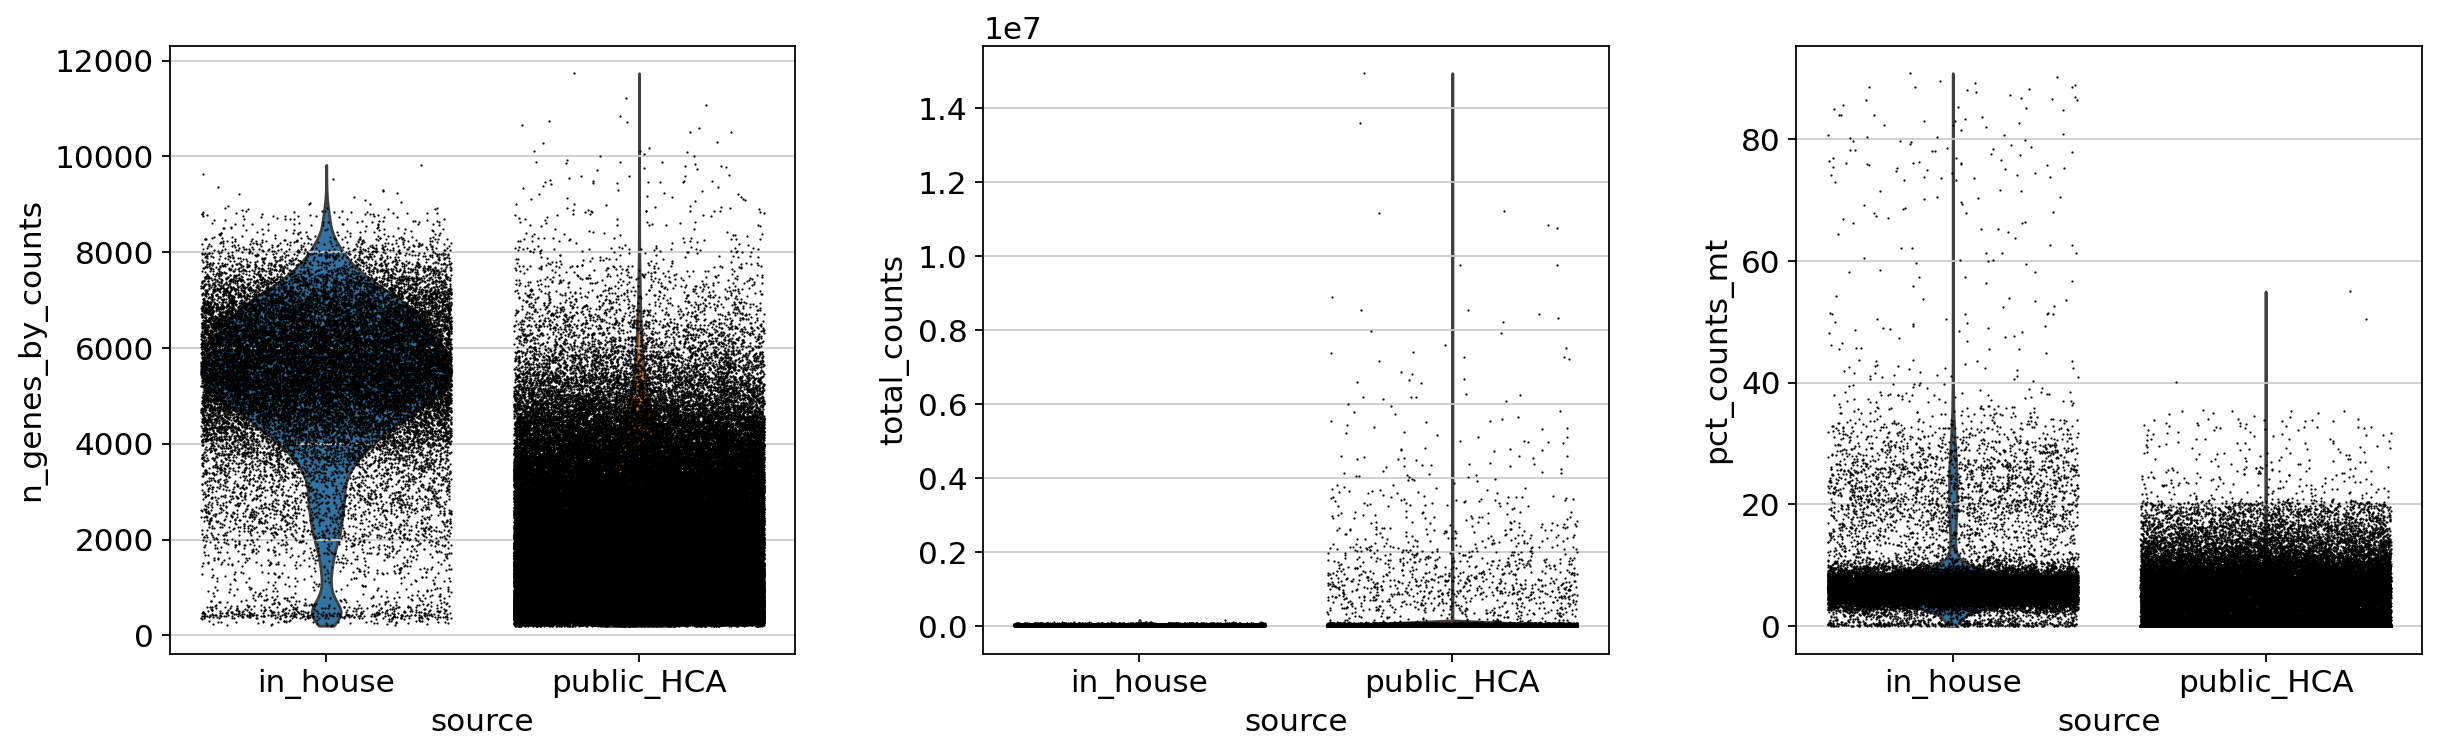

In [13]:
sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_genes(adata_combined, min_cells=3)

adata_combined.var['mt'] = adata_combined.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata_combined, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
)

# Visualize QC metrics split by source before filtering
sc.pl.violin(
    adata_combined,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    groupby='source',
    jitter=0.4,
    multi_panel=True,
)

In [14]:
adata_combined_filtered = adata_combined[adata_combined.obs.total_counts < 75000, :]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.n_genes > 1000, :]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.pct_counts_mt < 20, :]

print(adata_combined_filtered)
print(adata_combined_filtered.obs['source'].value_counts())

View of AnnData object with n_obs × n_vars = 110934 × 21669
    obs: 'sample', 'source', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'source_colors'
source
public_HCA    88239
in_house      22695
Name: count, dtype: int64


## 6. Normalize, Log-Transform, and Select HVGs

HVGs are selected with `batch_key='source'` so genes are ranked by variability within each source 
independently, then combined. This avoids selecting genes that vary only because of source differences.

In [15]:
adata_combined_filtered = adata_combined_filtered.copy()  # materialize view
adata_combined_filtered.layers['counts'] = adata_combined_filtered.X.copy()

sc.pp.normalize_total(adata_combined_filtered, target_sum=1e6)
sc.pp.log1p(adata_combined_filtered)
adata_combined_filtered.raw = adata_combined_filtered

sc.pp.highly_variable_genes(
    adata_combined_filtered,
    n_top_genes=3000,        # increased from 1200 — more genes improve integration #can calculate total variation left for different feature numbers; log-transform/center and  run PCA --> calculate variance of each component and sum up (orthogonal)
    subset=True,
    layer='counts',
    flavor='seurat_v3',
    batch_key='source',      # rank HVGs within each source independently
)

print(f'HVGs selected: {adata_combined_filtered.n_vars}')

HVGs selected: 3000


## 7. scVI Setup and Training

- `batch_key='source'`: corrects for in-house vs public technical differences  
- `categorical_covariate_keys=['sample']`: also accounts for fused/parental/resistant variation

In [16]:
scvi.model.SCVI.setup_anndata(
    adata_combined_filtered,
    layer='counts',
    batch_key='source',
    categorical_covariate_keys=['sample']
)
#run for many many epochs

In [ ]:
model = scvi.model.SCVI(adata_combined_filtered, n_latent=128) #n_latent == number of latent components -- how to summarize all data with only 30 "features" in summary
model.train(accelerator='cpu', max_epochs = 1000)  # use GPU (Apple Silicon)

/home/pvs13/venvs/scvi/lib/python3.12/site-packages/scvi/dataloaders/_data_splitting.py:258: UserWarning: 1 cells moved from training set to validation set. if you want to avoid it please use train_size parameter during train.
  self.n_train, self.n_val = validate_data_split(
/home/pvs13/venvs/scvi/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/pvs13/venvs/scvi/lib/python3.12/site-packages/ ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/pvs13/venvs/scvi/lib/python3.12/site-packages/lightning/fabric/plugins/e

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [30]:
# Save model so you don't have to retrain
model.save('scvi_HCA_lung_integration_model/', overwrite=True)

## 8. Latent Representation and Clustering

In [42]:
SCVI_LATENT_KEY = 'X_scVI'
adata_combined_filtered.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

sc.pp.neighbors(adata_combined_filtered, use_rep=SCVI_LATENT_KEY)

SCVI_CLUSTERS_KEY = 'leiden_scVI'
sc.tl.leiden(
    adata_combined_filtered,
    key_added=SCVI_CLUSTERS_KEY,
    resolution=0.3,
    flavor='igraph',
    n_iterations=2,
    directed=False,
)

sc.tl.umap(adata_combined_filtered, min_dist=0.3)

## 9. Visualization

Key plots to assess integration quality and cell type context.

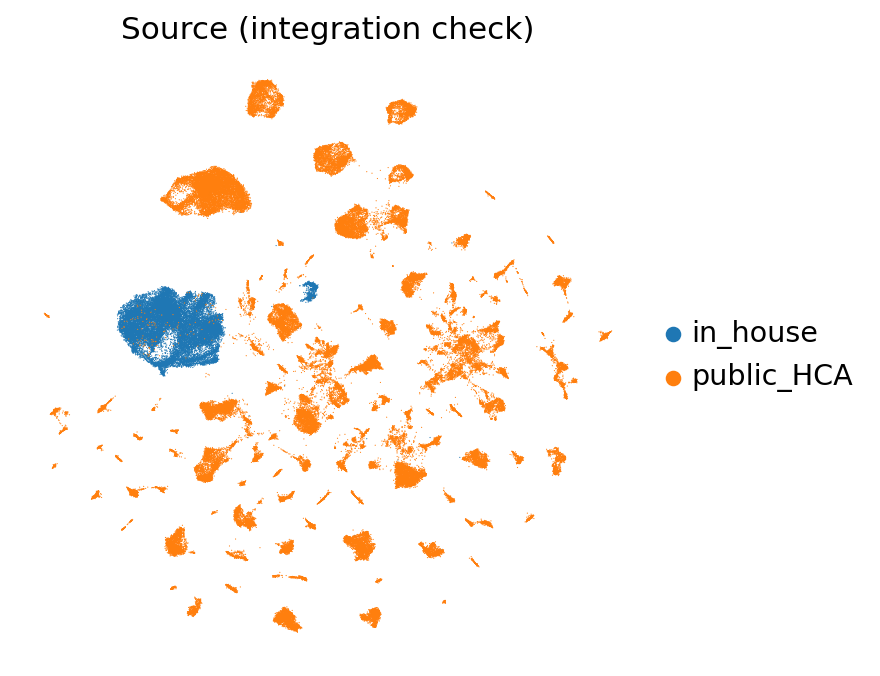

In [32]:
# Integration quality: in-house and HCA cells should intermingle if integration worked
sc.pl.umap(
    adata_combined_filtered,
    color=['source'],
    frameon=False,
    title='Source (integration check)',
)

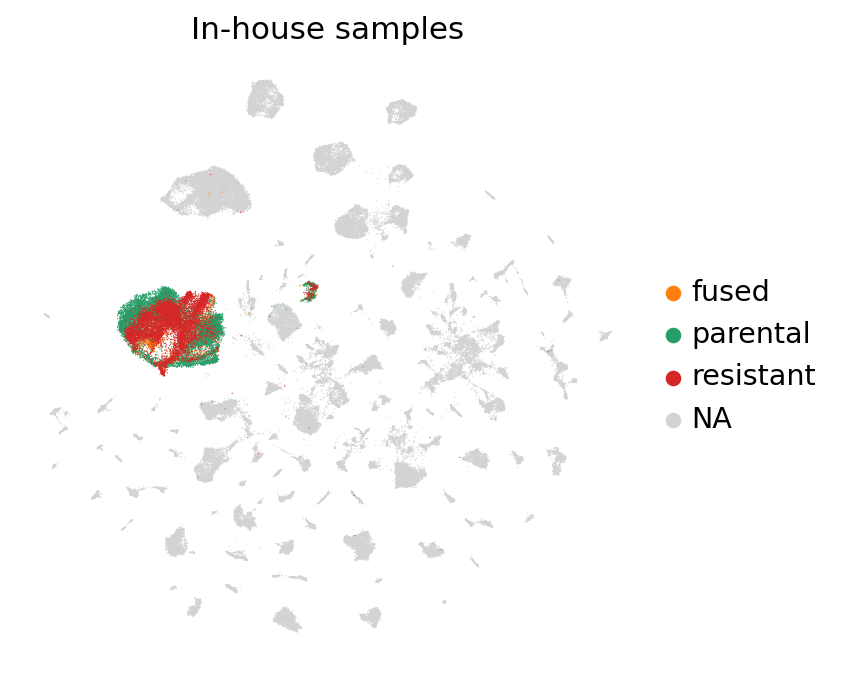

In [33]:
# In-house sample identity
sc.pl.umap(
    adata_combined_filtered,
    color=['sample'],
    frameon=False,
    groups=['fused', 'parental', 'resistant'],  # exclude HCA_lung from color
    title='In-house samples',
)

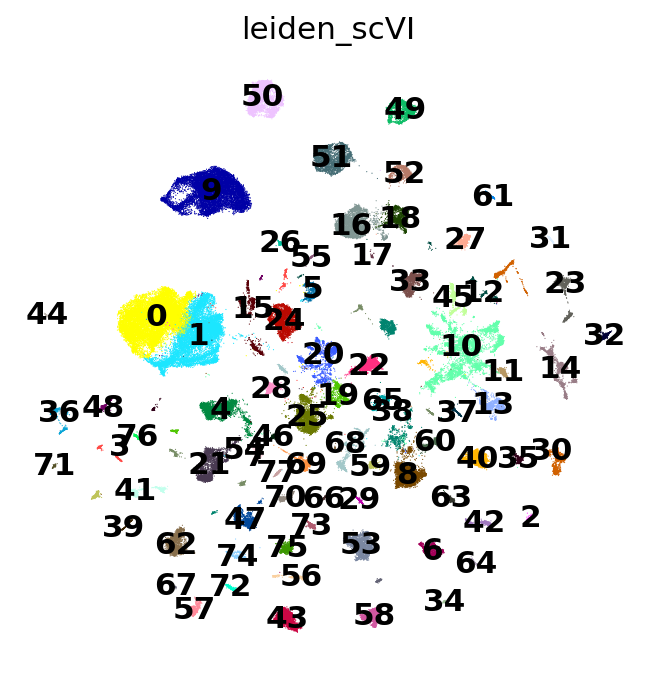

In [34]:
# Leiden clusters
sc.pl.umap(
    adata_combined_filtered,
    color=[SCVI_CLUSTERS_KEY],
    frameon=False,
    legend_loc='on data',
)

In [35]:
# HCA cell type annotations — shows which lung cell types your cells resemble
# 'cell_type' is the standard column in CellxGene Census objects
if 'cell_type' in adata_combined_filtered.obs.columns:
    sc.pl.umap(
        adata_combined_filtered,
        color=['cell_type'],
        frameon=False,
        legend_fontsize=7,
        title='Cell type (HCA annotations)',
    )
else:
    print('No cell_type column found. Check adata_combined_filtered.obs.columns')

No cell_type column found. Check adata_combined_filtered.obs.columns


## 10. Differential Expression — In-House Samples Only

Restrict DE to in-house cells so we compare fused/parental/resistant against each other,
not against HCA lung cells.

In [36]:
adata_inhouse_filtered = adata_combined_filtered[
    adata_combined_filtered.obs['source'] == 'in_house'
].copy()

print(adata_inhouse_filtered)
print(adata_inhouse_filtered.obs['sample'].value_counts())

AnnData object with n_obs × n_vars = 22695 × 3000
    obs: 'sample', 'source', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'source_colors', 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden_scVI', 'umap', 'sample_colors', 'leiden_scVI_colors'
    obsm: '_scvi_extra_categorical_covs', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
sample
parental     9438
resistant    7873
fused        5384
Name: count, dtype: int64


In [37]:
# Re-load the model and get latent for in-house subset only
# (model.differential_expression can subset internally via indices)
de_df = model.differential_expression(
    adata=adata_inhouse_filtered,
    groupby='sample',
    mode='change',
)
de_df.head()

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


DE...:   0%|          | 0/3 [00:00<?, ?it/s]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
SYK,0.9488,0.0512,2.919458,0.000003,0.000035,5.310128e-08,0.25,-2.639717,-2.172159,1.876594,...,0.004458,0.200915,0.004272,0.136907,0.005127,0.344891,False,fused vs Rest,fused,Rest
KLK7,0.9440,0.0560,2.824774,0.000426,0.000131,5.310128e-08,0.25,1.887977,1.773250,1.146006,...,3.429880,0.686875,0.898217,0.399861,4.043646,1.167688,False,fused vs Rest,fused,Rest
SERPINE2,0.9382,0.0618,2.720060,0.000147,0.000265,5.310128e-08,0.25,-0.842583,-0.843072,0.399561,...,1.251824,1.554108,0.656575,0.712842,1.484791,2.646661,False,fused vs Rest,fused,Rest
TRIM29,0.9312,0.0688,2.605270,0.000323,0.000090,5.310128e-08,0.25,2.101002,1.991189,1.327298,...,2.668761,0.526132,0.833210,0.307666,3.042251,0.835038,False,fused vs Rest,fused,Rest
KLK10,0.9254,0.0746,2.518085,0.000096,0.000036,5.310128e-08,0.25,1.415347,1.447871,0.813165,...,0.911380,0.234075,0.553863,0.193692,1.053954,0.386530,False,fused vs Rest,fused,Rest


In [38]:
markers = {}
cats = {'fused', 'resistant', 'parental'}
for c in cats:
    cid = f'{c} vs Rest'
    cell_type_df = de_df.loc[de_df.comparison == cid]
    cell_type_df = cell_type_df[cell_type_df.lfc_mean > 0]
    cell_type_df = cell_type_df[cell_type_df['bayes_factor'] > 3]
    cell_type_df = cell_type_df[cell_type_df['non_zeros_proportion1'] > 0.1]
    markers[c] = cell_type_df.index.tolist()[:3]

print('Top markers per sample:', markers)

Top markers per sample: {'fused': [], 'resistant': ['CD40', 'NLRP1', 'NPW'], 'parental': ['C1R', 'C1S', 'LINC01503']}


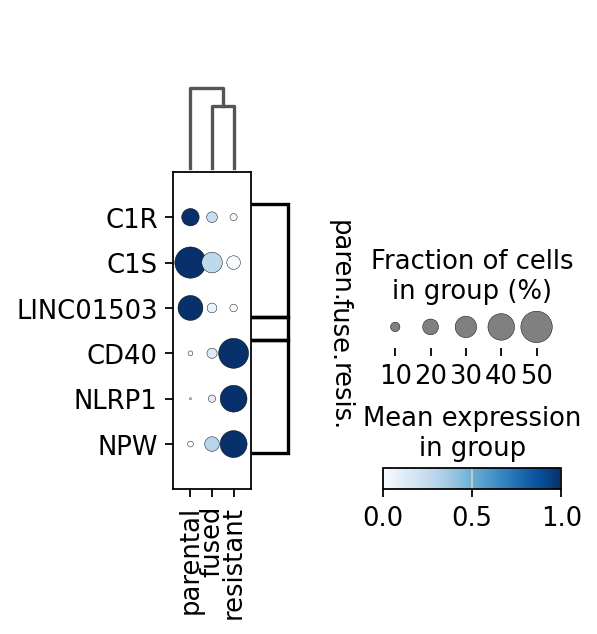

In [39]:
sc.tl.dendrogram(adata_inhouse_filtered, groupby='sample', use_rep='X_scVI')

sc.pl.dotplot(
    adata_inhouse_filtered,
    markers,
    groupby='sample',
    dendrogram=True,
    color_map='Blues',
    swap_axes=True,
    use_raw=True,
    standard_scale='var',
)

## 11. Cell Type Composition of In-House Samples

Shows what fraction of each in-house sample maps to each HCA-annotated cluster.

In [40]:
if 'cell_type' in adata_inhouse_filtered.obs.columns:
    composition = (
        adata_inhouse_filtered.obs
        .groupby(['sample', 'cell_type'])
        .size()
        .unstack(fill_value=0)
    )
    composition_norm = composition.div(composition.sum(axis=1), axis=0)

    composition_norm.T.plot(
        kind='bar',
        stacked=False,
        figsize=(14, 5),
        title='Cell type composition by in-house sample (HCA annotations)',
    )
    import matplotlib.pyplot as plt
    plt.ylabel('Fraction of cells')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No cell_type column — run cell type annotation first.')

No cell_type column — run cell type annotation first.


## 12. UMAP — In-House Cells Only

Plot just in-house cells on the shared latent UMAP to see where fused/parental/resistant land 
relative to the HCA-defined clusters.

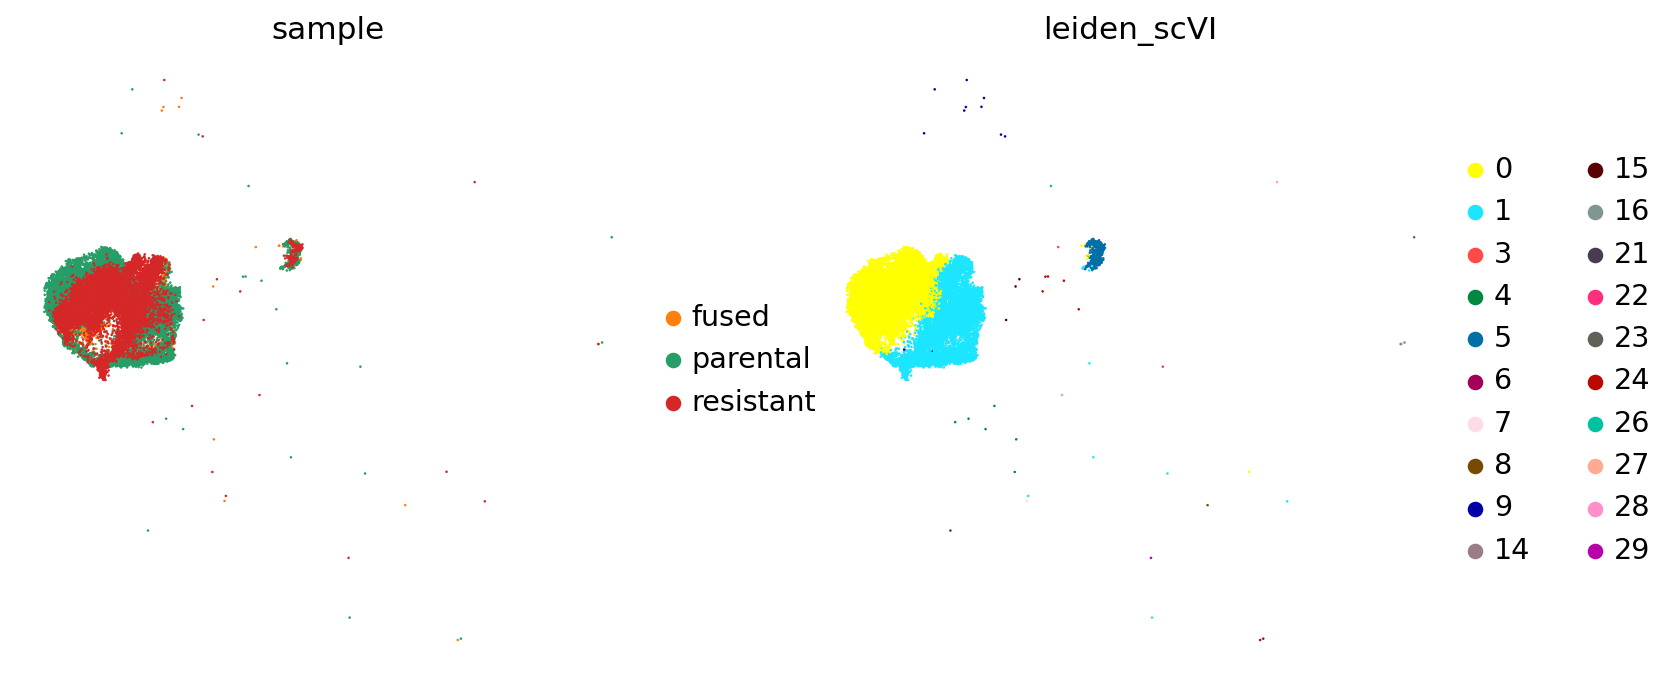

In [41]:
sc.pl.umap(
    adata_inhouse_filtered,
    color=['sample', SCVI_CLUSTERS_KEY],
    frameon=False,
    ncols=2,
)